# Plan Comments EDA
**Dataset:** `plan_comments.csv`  
**Goal:** Look at permit plan review comments to find patterns in complexity and delays that could help predict how long a permit will take.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/plan_comments.csv')
df['DocumentDate'] = pd.to_datetime(df['DocumentDate'])
df['Year'] = df['DocumentDate'].dt.year

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['DocumentDate'].min().date()} → {df['DocumentDate'].max().date()}")
df.head()


Rows: 26,299
Columns: ['PermitNum', 'DocumentTitle', 'URL', 'Subject', 'ReviewType', 'ReviewCycle', 'Comment', 'DocumentDate', 'Year']
Date range: 2022-01-20 → 2025-09-29


,PermitNum,DocumentTitle,URL,Subject,ReviewType,ReviewCycle,Comment,DocumentDate,Year
0,6524888-CN,Correction Letter-Structural Engineer-Cycle2,https://web.seattle.gov/dpd/edms/GetDocument?i...,00 Code Edition,Structural Engineer,2.0,This project has been reviewed for conformance...,2022-07-19 11:20:00,2022
1,6524888-CN,Correction Letter-Structural Engineer-Cycle2,https://web.seattle.gov/dpd/edms/GetDocument?i...,16 Gravity Design,Structural Engineer,2.0,"Section S4.3, please confirm double wall top p...",2022-07-19 11:20:00,2022
2,6524888-CN,Correction Letter-Structural Engineer-Cycle2,https://web.seattle.gov/dpd/edms/GetDocument?i...,16 Lateral Design,Structural Engineer,2.0,"Section 7,8/S4.1, for force transfered around ...",2022-07-19 11:20:00,2022
3,6524888-CN,Correction Letter-Structural Engineer-Cycle2,https://web.seattle.gov/dpd/edms/GetDocument?i...,17 Special Inspections,Structural Engineer,2.0,SBC 1704.2 - Complete and return the attached ...,2022-07-19 11:20:00,2022
4,6524888-CN,Correction Letter-Structural Engineer-Cycle2,https://web.seattle.gov/dpd/edms/GetDocument?i...,18 Foundations & Retaining Walls,Structural Engineer,2.0,"Sheet S3.0, for foundation grade beam shown on...",2022-07-19 11:20:00,2022


## 1. Data Overview

26,299 comments across 707 permits with 9 columns. ReviewCycle has the most missing data at about 6%, which is worth keeping in mind when looking at cycle-based analysis.

In [32]:
print("Shape")
print(df.shape)

print("\nDtypes & Nulls")
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})
print(summary)


Shape
(26299, 9)

Dtypes & Nulls
                        dtype  null_count  null_percentage  n_unique
PermitNum              object           0             0.00       707
DocumentTitle          object           0             0.00       562
URL                    object           0             0.00      6296
Subject                object           0             0.00      1946
ReviewType             object         342             1.30        31
ReviewCycle           float64        1606             6.11        10
Comment                object          63             0.24     22903
DocumentDate   datetime64[ns]           0             0.00      5882
Year                    int64           0             0.00         4


## 2. Complexity per Permit

Group comments by permit to get a per-permit summary covering total comments, max review cycle reached, number of departments involved, and how long the review took. This gives a sense of how much complexity varies across permits.

In [33]:
permit_stats = df.groupby('PermitNum').agg(
    total_comments=('Comment', 'count'),
    max_cycle=('ReviewCycle', 'max'),
    n_review_types=('ReviewType', 'nunique'),
    date_span_days=('DocumentDate', lambda x: (x.max() - x.min()).days)
).reset_index()

print("Per-Permit Stats")
print(permit_stats[['total_comments','max_cycle','n_review_types','date_span_days']].describe().round(1))


Per-Permit Stats
       total_comments  max_cycle  n_review_types  date_span_days
count           707.0      707.0           707.0           707.0
mean             37.1        2.5             5.2           159.6
std              30.1        1.3             2.0           199.9
min               1.0        1.0             1.0             0.0
25%              17.0        2.0             4.0            43.0
50%              31.0        2.0             5.0            99.0
75%              50.0        3.0             6.0           186.5
max             312.0       10.0            11.0          1329.0


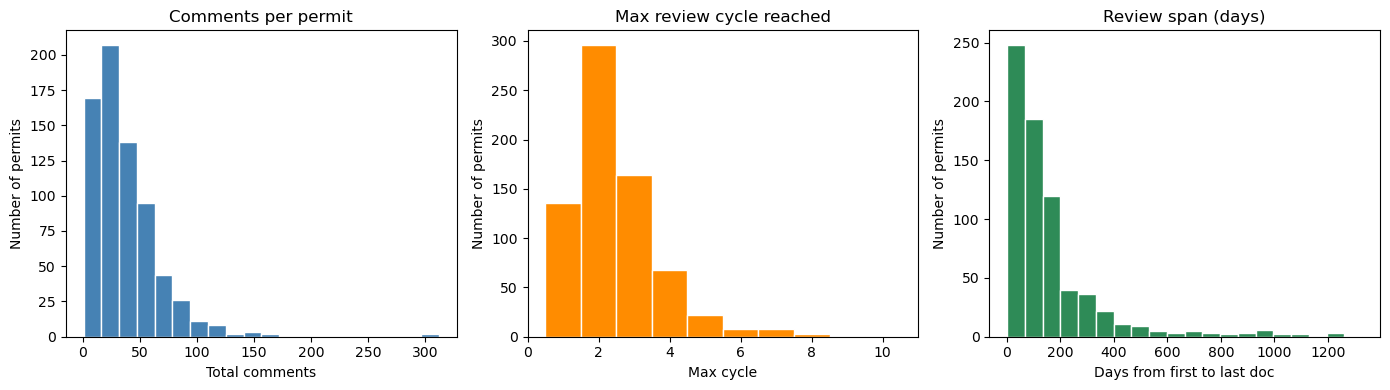

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(permit_stats['total_comments'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Comments per permit')
axes[0].set_xlabel('Total comments')
axes[0].set_ylabel('Number of permits')

axes[1].hist(permit_stats['max_cycle'].dropna(), bins=range(1, 12), align='left', color='darkorange', edgecolor='white')
axes[1].set_title('Max review cycle reached')
axes[1].set_xlabel('Max cycle')
axes[1].set_ylabel('Number of permits')

axes[2].hist(permit_stats['date_span_days'], bins=20, color='seagreen', edgecolor='white')
axes[2].set_title('Review span (days)')
axes[2].set_xlabel('Days from first to last doc')
axes[2].set_ylabel('Number of permits')

plt.tight_layout()
plt.savefig('../output/permit_complexity.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Review Type Distribution

A look at which departments are most active overall. Some review types such as zoning and drainage dominate comment volume.

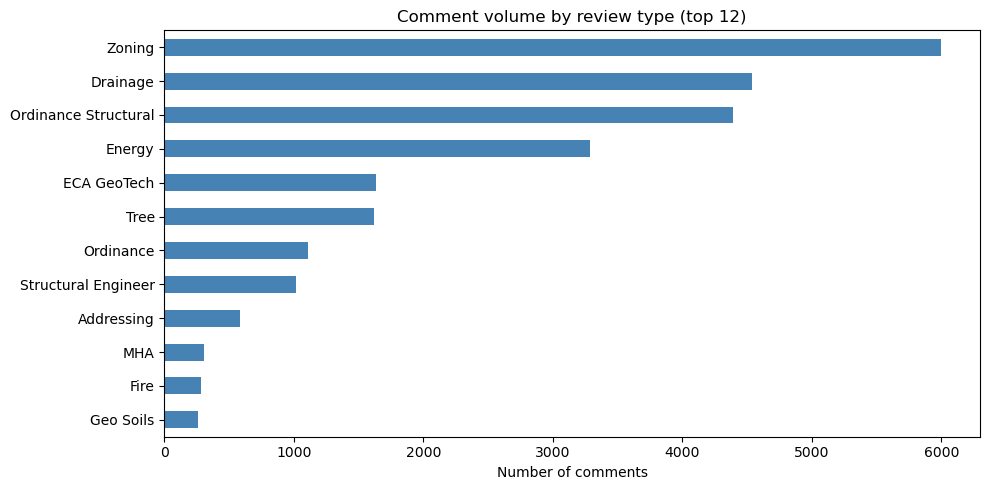

Zoning                  5999
Drainage                4536
Ordinance Structural    4392
Energy                  3290
ECA GeoTech             1633
Tree                    1619
Ordinance               1111
Structural Engineer     1013
Addressing               588
MHA                      305
Fire                     283
Geo Soils                262
Name: ReviewType, dtype: int64


In [ ]:
rt_counts = df['ReviewType'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
rt_counts.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Comment volume by review type (top 12)')
ax.set_xlabel('Number of comments')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../output/review_type.png', dpi=150, bbox_inches='tight')
plt.show()

print(rt_counts)

## 4. Review Cycles

Most permits resolve in cycle 1-2. Permits requiring 3+ cycles are strong delay signals.

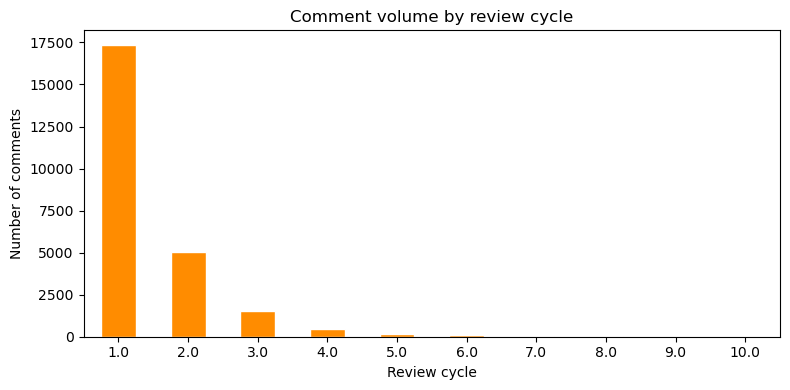

 cycle  comments  percentage_of_total  cumulative_percentage
     1     17352                 70.3                   70.3
     2      5036                 20.4                   90.7
     3      1545                  6.3                   96.9
     4       465                  1.9                   98.8
     5       135                  0.5                   99.4
     6        92                  0.4                   99.7
     7        34                  0.1                   99.9
     8        30                  0.1                  100.0
     9         2                  0.0                  100.0
    10         2                  0.0                  100.0

Total: 24,693 comments

Cycle 1:  17,352 comments (70.3%)
Cycle 2+: 7,341 comments (29.7%)


In [ ]:
cycle_counts = df['ReviewCycle'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
cycle_counts.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Comment volume by review cycle')
ax.set_xlabel('Review cycle')
ax.set_ylabel('Number of comments')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../output/review_cycle.png', dpi=150, bbox_inches='tight')
plt.show()

# Cycle-by-cycle breakdown
total = cycle_counts.sum()
cycle_df = pd.DataFrame({
    'cycle': cycle_counts.index.astype(int),
    'comments': cycle_counts.values,
    'percentage_of_total': (cycle_counts.values / total * 100).round(1),
    'cumulative_percentage': (cycle_counts.values.cumsum() / total * 100).round(1)
})
print(cycle_df.to_string(index=False))
print(f"\nTotal: {total:,} comments")
c1 = cycle_counts[cycle_counts.index == 1.0].sum()
c_later = cycle_counts[cycle_counts.index >= 2].sum()
print(f"\nCycle 1:  {c1:,} comments ({c1/total*100:.1f}%)")
print(f"Cycle 2+: {c_later:,} comments ({c_later/total*100:.1f}%)")


## 5. Review Types that are Delay Drivers

Review types that generate the most comments in cycle 2+. These are the departments causing applicants to resubmit.

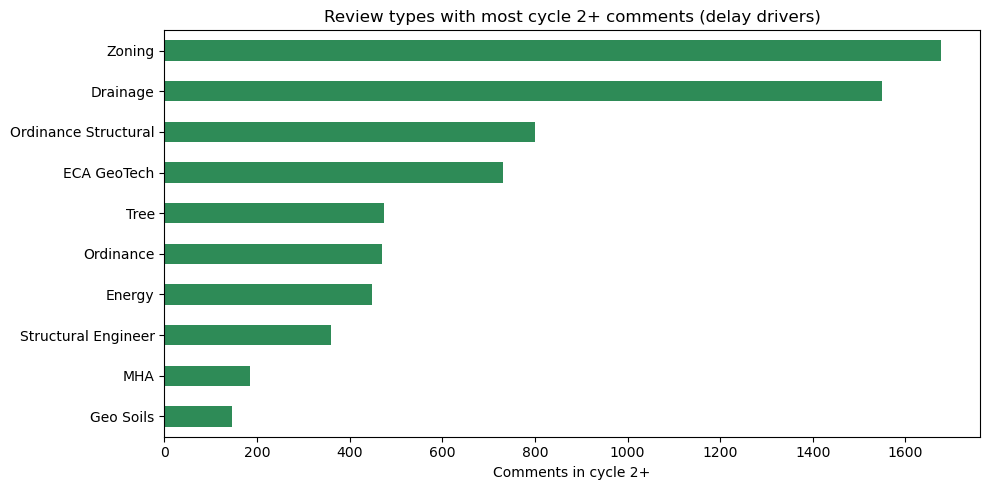

Zoning                  1677
Drainage                1549
Ordinance Structural     800
ECA GeoTech              732
Tree                     474
Ordinance                470
Energy                   448
Structural Engineer      359
MHA                      184
Geo Soils                146
Name: ReviewType, dtype: int64


In [37]:
repeat = df[df['ReviewCycle'] >= 2]
repeat_by_type = repeat['ReviewType'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
repeat_by_type.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Review types with most cycle 2+ comments (delay drivers)')
ax.set_xlabel('Comments in cycle 2+')
plt.tight_layout()
plt.savefig('../output/delay_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

print(repeat_by_type)


## 6. Top Subjects (Cycle 2+)

The specific correction categories that applicants most commonly miss on their first submission.

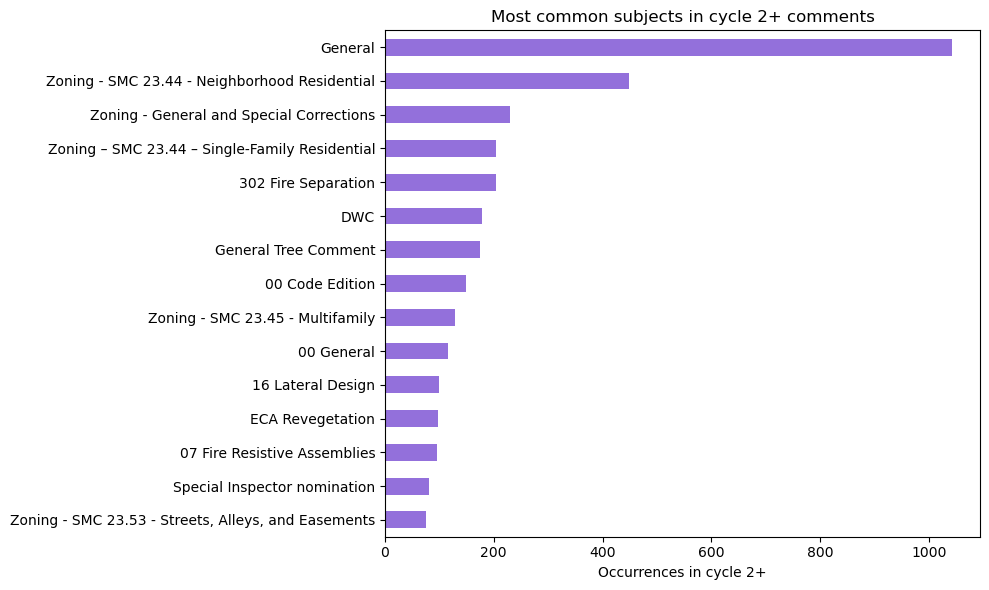

In [ ]:
top_subjects = df[df['ReviewCycle'] >= 2]['Subject'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_subjects.sort_values().plot(kind='barh', ax=ax, color='mediumpurple')
ax.set_title('Most common subjects in cycle 2+ comments')
ax.set_xlabel('Occurrences in cycle 2+')
plt.tight_layout()
plt.savefig('../output/top_subjects.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Volume Over Time

Shows how comment volume is spread across years. 2024 and 2025 make up the bulk of the data so earlier years should be interpreted with that in mind.

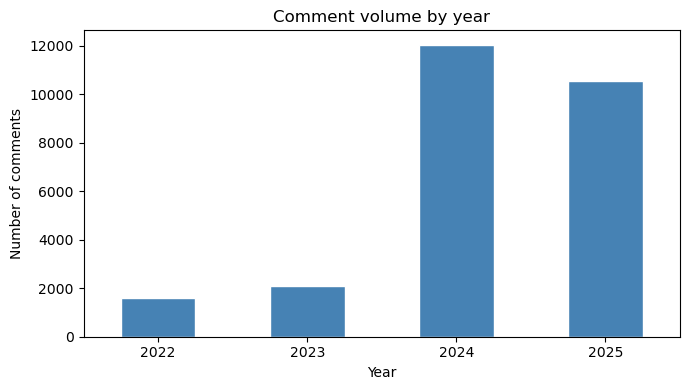

Year
2022     1606
2023     2096
2024    12039
2025    10558
dtype: int64


In [39]:
# Exclude 2026 (incomplete year) and pre-2022 for cleanliness
yearly = df[df['Year'].between(2022, 2025)].groupby('Year').size()

fig, ax = plt.subplots(figsize=(7, 4))
yearly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Comment volume by year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of comments')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../output/volume_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(yearly)


## 8. Key Takeaways

**Dataset**
- 26,299 comments across 707 permits, 2022–2025
- 2022 and 2023 are underrepresented (1,606 and 2,096 records) compared to 2024–2025 (~12,000 each)

**Review cycles**
- 70% of all comments come in during cycle 1 and 90% are resolved by cycle 2
- Permits reaching cycle 3+ are the exception and likely the biggest drivers of long timelines

**Top delay drivers**
- Zoning (1,677) and Drainage (1,549) have the most cycle 2+ comments by far
- Both also lead overall comment volume meaning they're common and hard to get right on the first submission

**Permit complexity**
- The average permit has 37 comments, but ranges from 1 to 312
- Most permits involve 5 review departments; permits with more departments tend to take longer